In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import random
import time
#import scimap as sm
#import anndata as ad
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.model_selection import GridSearchCV
from sksurv.metrics import concordance_index_censored
from functools import partial
from helperFunctions import *
from sklearn.metrics import make_scorer
from smallestEnclosingCircle import make_circle
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from ecd_helperFunctions import *

### Topographical Correlation Map Feature Based Cox-PH Model

**Step 1: Data Preprocessing**
- Load data into correct format for TCM
- Divide data into ROIs and save as .hd5 files<br>

**Step 2: Generate Complete Spatial Randomness Datasets**
- Generate datasets with equal number of cells as each ROI
- Create "paired" CSR datasets for each ROI<br>

**Step 3: Calculate Topographical Correlation Maps**
- Calculate TCM for both real and CSR datasets<br>

**Step 4: Compare Positive and Negative TCM Distributions**
- For positive TCM values, use K-S test to compare real and CSR datasets
- For negative TCM values, use K-S test to compare real and CSR datasets<br>

**Step 5: Rank ROIs based on K-S Score**
- Use rank to select the top 10 ROIs with the most positive correlation and top 10 ROIs with the most negative correlation between cell markers<br>

**Step 6: Calculate the distance between the centroids of the top 10 ROIs**
- Calculate the pairwise distance between the of the top 10 postive and negative ROIs
- This will result pos_TCM_dist_12, pos_TCM_dist_23, pos_TCM_dist_34, etc. for positive TCM values and neg_TCM_dist_12, neg_TCM_dist_23, neg_TCM_dist_34, etc. for negative TCM values<br>

**Step 7: Calculate the Cox-PH model with L2 regularization**
- The model will have 29 covariates added per marker pair that is assessed in the TCM

### **STEP ONE**: Data Preprocessing

In [2]:
# Get all .csv files in one list
data_dir = '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/'
data_parent_dir = os.listdir(data_dir)

file_paths = []
for i in range(len(data_parent_dir)):
    files = os.listdir(data_dir + data_parent_dir[i])
    csv_files = [file for file in files if file.endswith('.csv')]
    for file in csv_files:
        file_path = os.path.join(data_dir, data_parent_dir[i], file)
        file_paths.append(file_path)

print(file_paths)

['/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC07/P37_S35-CRC07.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC35/P37_S78-CRC35.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC14/P37_S46-CRC14.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC26/P37_S63-CRC26.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC21/P37_S58-CRC21.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC19/P37_S51-CRC19.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC13/P37_S45-CRC13.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC32/P37_S75-CRC32.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC38/P37_S81-CRC38.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC33_02/P37_S76_02-CRC33_02.csv', '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/CRC04/P37_S32-C

In [ ]:
# Define markers of interest (reduce the file size needed to save)
markers = ['CD45', 'CD4', 'SMA', 'PD-L1', 'Pan-CK']
grid_directory = '/michorlab/ecdyer/multiplex_spatial/crc_grid_data/cph_grids/'

##### Only run the below step if you want to generate NEW grid files for the TCM

In [ ]:
# Apply GMM to each file and save the grid
for f in file_paths:
    df = apply_gmm([f], markers)
    grid_file_name = grid_directory + f.split('/')[-1].split('.')[0] + '_gmm.h5'
    create_tile_rois(df, tile_size=5000, save=True, save_hdf5=grid_file_name)

### **STEP TWO/THREE/FOUR**: Generate Complete Spatial Randomness Datasets, Calculate TCMs, and Calculate K-S Scores
This is very computationally intensive. Do not run this in a notebook on an entire dataset. Instead, run this in a script on a cluster with multithreading. Multithreading functionality can be achieved with the helper function `ecd_helperFunctions.multithread_compare_tcm()`.

In [ ]:
cwd = '/michorlab/ecdyer/multiplex_spatial/crc_grid_data/cph_grids'
short_grid_files = os.listdir(cwd)
grid_files = [os.path.join(cwd, f) for f in short_grid_files]
markers = ['CD45_status', 'PD-L1_status']
keep_cols = ['X_centroid', 'Y_centroid', 'CellID']
labels  = {1: 'Lymphocytes',
            2: 'PD-L1'}
rename_cols_dict = {'X_centroid': 'x', 
                    'Y_centroid': 'y'}
save_tcm_plot_path = '/michorlab/ecdyer/multiplex_spatial/figures/tcm_plots/'
save_csr_plot_path = '/michorlab/ecdyer/multiplex_spatial/figures/csr_tcm_plots/'
save_ks_results_path = '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_pdl1/'
save_tcm_path = '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_pdl1/'
save_csr_tcm_path = '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_pdl1/'

for grid_file in grid_files:
    compare_tcm(grid_file, 
        markers,
        keep_cols,
        labels,
        visualiseStages=False,
        #save_tcm_plot_path=save_tcm_plot_path,
        #save_csr_plot_path=save_csr_plot_path,
        #save_tcm_path=save_tcm_path,
        #save_csr_tcm_path=save_csr_tcm_path,
        save_ks_results_path=save_ks_results_path,
        rename_cols_dict=rename_cols_dict,
        plot_point_cloud=False)

### **STEP FIVE/SIX**: Rank ROIs and Calculate Pairwise Distances

In [17]:
ks_results_dir = '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_sma/'
grid_files = '/michorlab/ecdyer/multiplex_spatial/crc_grid_data/cph_grids/'
save_dir = '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_sma_ranked/'

test_ks_rank_grid_dict = rank_and_calculate_distance(ks_results_dir, 
                                                     grid_files, 
                                                     save_dir=save_dir,
                                                     log_scale_ks=True)

In [ ]:
ks_results_directories = ['/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_sma/',
                          '/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_cd45/',
                          'michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_sma/']

save_dirs = ['/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_sma_ranked',
                '/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_cd45_ranked',
                '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_sma_ranked']

grid_files = '/michorlab/ecdyer/multiplex_spatial/crc_grid_data/cph_grids/'

for i in range(len(ks_results_directories)):
    test_ks_rank_grid_dict = rank_and_calculate_distance(ks_results_directories[i], 
                                                         grid_files, 
                                                         save_dir=save_dirs[i],
                                                         log_scale_ks=True)

### STEP SEVEN: Calculate Survival Models
1. Cox-PH model with L2 regularization
2. Reglularized Cox Model with Elastic Net Regularization
3. Random Survival Forest Model

In [66]:
clinical_data_file = '/michorlab/ecdyer/multiplex_spatial/orion_crc_clinical_variables.csv'

ks_results_directories = ['/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_sma_ranked',
                '/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_cd45_ranked',
                '/michorlab/ecdyer/multiplex_spatial/tcm_results/cd45_sma_ranked']

markers = ['pdl1_sma', 'pdl1_cd45', 'cd45_sma']
save_path = '/michorlab/ecdyer/multiplex_spatial/tcm_results/tcm_clin_vars.csv'

for i in range(len(ks_results_directories)):
    if i == 0:
        combine_clinical_and_tcm(clinical_data_file,
                                ks_results_directories[i],
                                save_path,
                                markers[i])
    else:
        clinical_data_file = save_path
    combine_clinical_and_tcm(clinical_data_file,
                                ks_results_directories[i],
                                save_path,
                                markers[i])

In [78]:
# Column Names: OSDays, OSCensor

tcm_clin_vars = pd.read_csv('/michorlab/ecdyer/multiplex_spatial/tcm_results/tcm_clin_vars.csv')
tcm_clin_vars = tcm_clin_vars.drop(tcm_clin_vars[tcm_clin_vars['Specimen_ID'] == 'C15'].index)

tcm_clin_vars['OSCensor'] = tcm_clin_vars['OSCensor'].astype(bool)

y = np.array([(row['OSCensor'], row['OSDays']) for _, row in tcm_clin_vars.iterrows()], dtype=[('OSCensor', bool), ('OSDays', float)])

columns_to_keep = [col for col in tcm_clin_vars.columns if 'distance' in col or 'ks' in col]
covariates = tcm_clin_vars[columns_to_keep]

# Handle missing values by imputation (filling with the mean value)
covariates.fillna(0, inplace=True)

# Standardize the covariates
scaler = StandardScaler()
scaler.fit(covariates)
X = scaler.fit_transform(covariates)

# Define the model with L2 regularization
coxph_model = make_pipeline(
    StandardScaler(),
    CoxPHSurvivalAnalysis(alpha=1.0)  # alpha is the regularization strength
)

# # Hyperparameter tuning
# param_grid = {'coxphsurvivalanalysis__alpha': np.logspace(-4, 4, 10)}
# grid_search = GridSearchCV(coxph_model, param_grid, cv=5)
# grid_search.fit(X, y)

# # Best model
# best_model = grid_search.best_estimator_
# best_alpha = grid_search.best_params_['coxphsurvivalanalysis__alpha']
# print(f"Best alpha: {best_alpha}")

# Evaluate the model
# Fit the StandardScaler before using it to transform the data
scaler.fit(X)

# Calculate the concordance index
c_index = concordance_index_censored(y["OSCensor"], y["OSDays"], coxph_model.predict(X))
print(f"Concordance index: {c_index[0]}")

/tmp/ipykernel_1065324/2845505859.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# Load the data
tcm_clin_vars = pd.read_csv('/michorlab/ecdyer/multiplex_spatial/tcm_results/tcm_clin_vars.csv')
tcm_clin_vars = tcm_clin_vars.drop(tcm_clin_vars[tcm_clin_vars['Specimen_ID'] == 'C15'].index)

# Convert OSCensor to boolean
tcm_clin_vars['OSCensor'] = tcm_clin_vars['OSCensor'].astype(bool)

# Create the structured array for the survival analysis
y = np.array([(row['OSCensor'], row['OSDays']) for _, row in tcm_clin_vars.iterrows()], dtype=[('OSCensor', bool), ('OSDays', float)])

# Select covariates
columns_to_keep = [col for col in tcm_clin_vars.columns if 'distance' in col or 'ks' in col]
covariates = tcm_clin_vars[columns_to_keep]

# Handle missing values by imputation (filling with the mean value)
covariates.fillna(0, inplace=True)

# Standardize the covariates
scaler = StandardScaler()
scaler.fit(covariates)
X = scaler.transform(covariates)

# Define the model with L2 regularization
coxph_model = make_pipeline(
	StandardScaler(),
	CoxPHSurvivalAnalysis(alpha=1.0)  # alpha is the regularization strength
)

# Custom scorer for concordance index
def concordance_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return concordance_index_censored(y["OSCensor"], y["OSDays"], pred)[0]

# Make the scorer
concordance_scorer = make_scorer(concordance_scorer, greater_is_better=True)

# Cross-validation to evaluate the model
scores = cross_val_score(make_pipeline(StandardScaler(), coxph_model), X, y, cv=5, scoring=concordance_scorer)
mean_c_index = np.mean(scores)
print(f"Mean Concordance Index from 5-fold Cross-Validation: {mean_c_index}")

# Fit the model
coxph_model.fit(X, y)

# Calculate the concordance index
c_index = concordance_index_censored(y["OSCensor"], y["OSDays"], coxph_model.predict(X))
print(f"Concordance index: {c_index[0]}")

/tmp/ipykernel_1065324/2601883632.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'neg_root_mean_squared_error', 'completeness_score', 'precision_macro', 'roc_auc_ovo', 'precision_samples', 'f1_macro', 'r2', 'rand_score', 'recall_macro', 'neg_median_absolute_error', 'positive_likelihood_ratio', 'roc_auc_ovr', 'average_precision', 'neg_mean_absolute_error', 'fowlkes_mallows_score', 'f1_micro', 'f1_weighted', 'neg_brier_score', 'matthews_corrcoef', 'jaccard', 'neg_log_loss', 'precision_weighted', 'balanced_accuracy', 'f1', 'precision_micro', 'neg_negative_likelihood_ratio', 'roc_auc_ovo_weighted', 'jaccard_macro', 'top_k_accuracy', 'recall_micro', 'roc_auc', 'neg_mean_gamma_deviance', 'roc_auc_ovr_weighted', 'jaccard_weighted', 'adjusted_rand_score', 'adjusted_mutual_info_score', 'precision', 'neg_mean_absolute_percentage_error', 'v_measure_score', 'neg_mean_poisson_deviance', 'explained_variance', 'recall_weighted', 'jaccard_micro', 'mutual_info_score', 'neg_mean_squared_log_error'

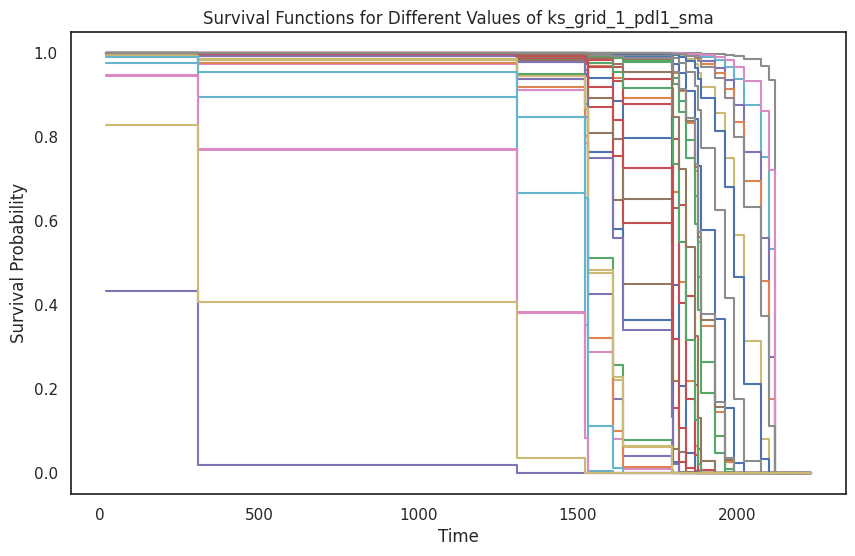

In [83]:
# Plot survival functions for different covariate values
def plot_survival_function(model, covariates, covariate_name, values):
    fig, ax = plt.subplots(figsize=(10, 6))
    for value in values:
        # Create a copy of the covariates and set the specific covariate to the given value
        covariates_copy = covariates.copy()
        covariates_copy[covariate_name] = value
        covariates_transformed = scaler.transform(covariates_copy)
        
        # Predict survival function
        survival_function = model.predict_survival_function(covariates_transformed)
        
        # Plot survival function
        for fn in survival_function:
            ax.step(fn.x, fn(fn.x), where="post", label=f"{covariate_name}={value}")
    
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival Probability")
    #ax.legend()
    plt.title(f"Survival Functions for Different Values of {covariate_name}")
    plt.show()

# Example: Plot survival functions for a covariate 'ks1'
plot_survival_function(coxph_model.named_steps['coxphsurvivalanalysis'], covariates, 'ks_grid_1_pdl1_sma', [0.2])

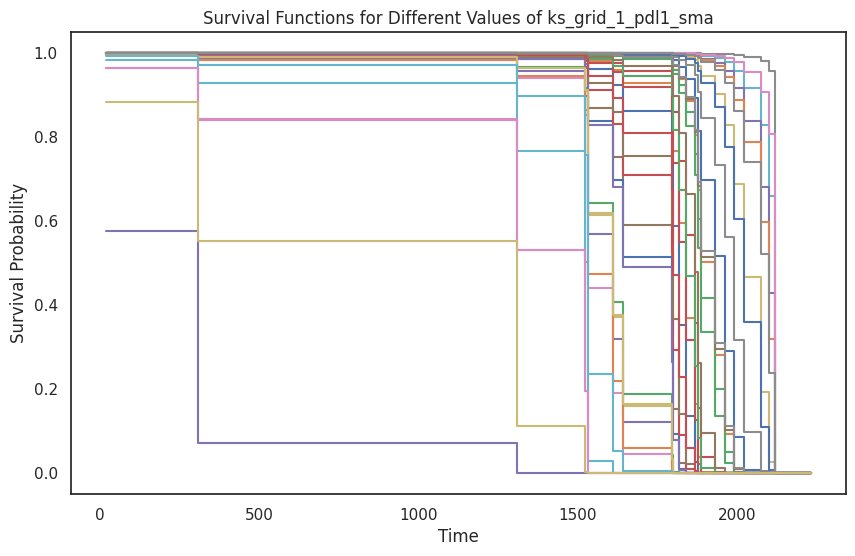

In [85]:
plot_survival_function(coxph_model.named_steps['coxphsurvivalanalysis'], covariates, 'ks_grid_1_pdl1_sma', [0.6])

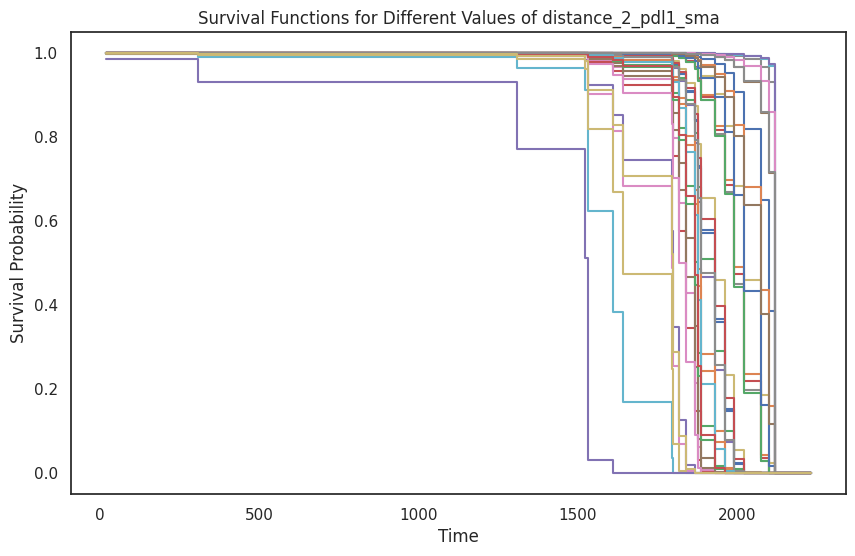

In [90]:
plot_survival_function(coxph_model.named_steps['coxphsurvivalanalysis'], covariates, 'distance_2_pdl1_sma', [5000])

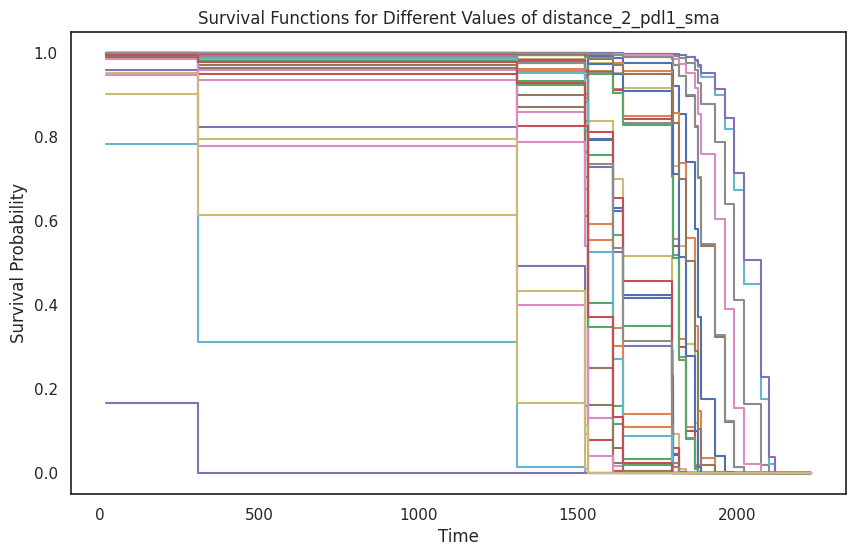

In [89]:
plot_survival_function(coxph_model.named_steps['coxphsurvivalanalysis'], covariates, 'distance_2_pdl1_sma', [50000])

In [68]:
# Example Code
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.model_selection import GridSearchCV
from sksurv.metrics import concordance_index_censored

# Prepare the data in the required format
# y should be a structured array with fields 'event' and 'time'
y = np.array([(row['event'], row['time']) for _, row in data.iterrows()], dtype=[('event', bool), ('time', float)])

# Standardize the covariates
X = scaler.fit_transform(data[covariate_columns])

# Define the model with L2 regularization
coxph_model = make_pipeline(
    StandardScaler(),
    CoxPHSurvivalAnalysis(alpha=1.0)  # alpha is the regularization strength
)

# Hyperparameter tuning
param_grid = {'coxphsurvivalanalysis__alpha': np.logspace(-4, 4, 10)}
grid_search = GridSearchCV(coxph_model, param_grid, cv=5)
grid_search.fit(X, y)

# Best model
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['coxphsurvivalanalysis__alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate the model
c_index = concordance_index_censored(y["event"], y["time"], best_model.predict(X))
print(f"Concordance index: {c_index[0]}")

NameError: name 'data' is not defined

### Heatmap Function Scratch Work

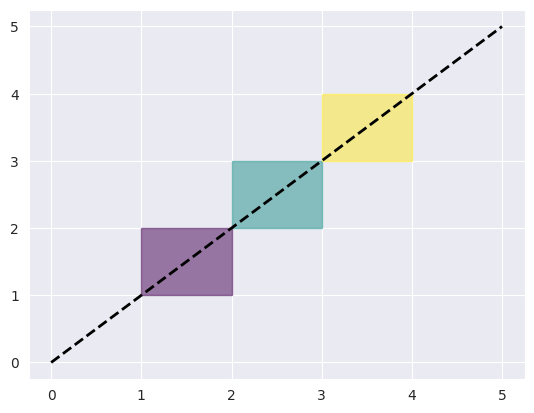

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style('darkgrid')

def generate_heatmap(df, x_min_col, x_max_col, y_min_col, y_max_col, ks_stat_col, baseline_plot_func, **baseline_plot_kwargs):
    """
    Generate a heatmap based on bounding box coordinates and ks_stat values.

    Parameters:
    - df: pandas DataFrame containing the bounding box coordinates and ks_stat values.
    - x_min_col: Column name for x-min values.
    - x_max_col: Column name for x-max values.
    - y_min_col: Column name for y-min values.
    - y_max_col: Column name for y-max values.
    - ks_stat_col: Column name for ks_stat values.
    - baseline_plot_func: Function to create the baseline plot.
    - baseline_plot_kwargs: Additional keyword arguments for the baseline plot function.
    """
    # Extract bounding box coordinates and ks_stat values
    x_min = df[x_min_col]
    x_max = df[x_max_col]
    y_min = df[y_min_col]
    y_max = df[y_max_col]
    ks_stat = df[ks_stat_col]

    # Normalize ks_stat values to range [0, 1]
    norm_ks_stat = (ks_stat - ks_stat.min()) / (ks_stat.max() - ks_stat.min())

    # Create the baseline plot
    fig, ax = plt.subplots()
    baseline_plot_func(ax, **baseline_plot_kwargs)

    # Overlay translucent rectangles based on bounding box coordinates and normalized ks_stat values
    for i in range(len(df)):
        rect = plt.Rectangle((x_min[i], y_min[i]), x_max[i] - x_min[i], y_max[i] - y_min[i],
                             color=sns.color_palette("viridis", as_cmap=True)(norm_ks_stat[i]), alpha=0.5)
        ax.add_patch(rect)

    # Display the plot
    plt.show()

# Example usage
if __name__ == "__main__":
    # Sample DataFrame
    data = {
        'x_min': [1, 2, 3],
        'x_max': [2, 3, 4],
        'y_min': [1, 2, 3],
        'y_max': [2, 3, 4],
        'ks_stat': [0.1, 0.5, 0.9]
    }
    df = pd.DataFrame(data)

    # Define a simple baseline plot function
    def baseline_plot(ax, **kwargs):
        ax.plot([0, 5], [0, 5], 'k--', lw=2)

    # Generate the heatmap
    generate_heatmap(df, 'x_min', 'x_max', 'y_min', 'y_max', 'ks_stat', baseline_plot)


In [ ]:
grid_files = '/michorlab/ecdyer/multiplex_spatial/crc_grid_data/cph_grids/'
sample_files = '/michorlab/labsyspharm_ORION-CRC/labsyspharm_ORION-CRC/aws_data/'
results_directory = '/michorlab/ecdyer/multiplex_spatial/tcm_results/pdl1_cd45/'
save_directory = '/michorlab/ecdyer/multiplex_spatial/figures/pdl1_cd45_heatmaps/'

generate_grid_heatmap(grid_files,
                        sample_files,
                        results_directory,
                        save_directory=save_directory,
                        save_plot=True,
                        cmap='magma')